In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in lpa)')

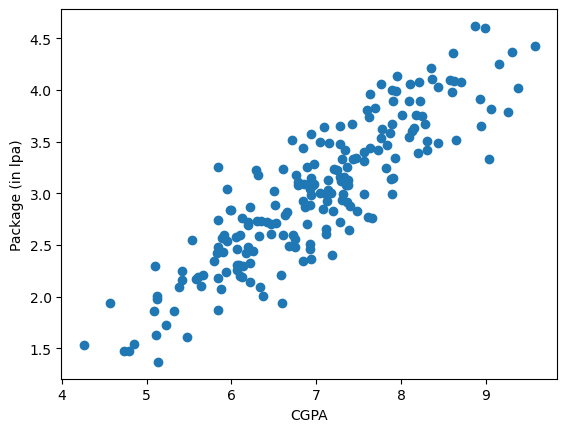

In [5]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [6]:
X = df.iloc[:, 0:1]
Y = df.iloc[:, -1]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [12]:
Y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [13]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

array([3.89111601])

In [14]:
lr.predict(X_test.iloc[1].values.reshape(1,1))

array([3.09324469])

Text(0, 0.5, 'Package (in lpa)')

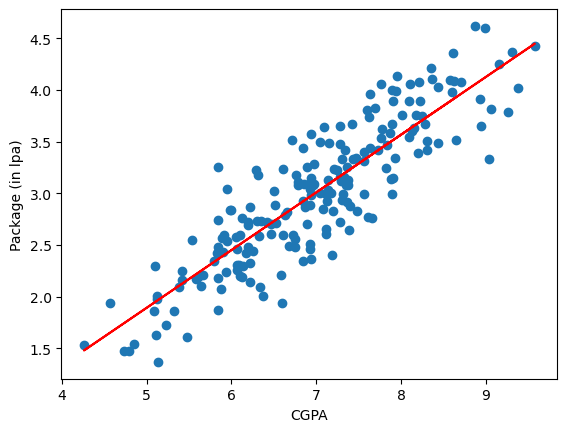

In [15]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [16]:
m = lr.coef_
m

array([0.55795197])

In [17]:
b = lr.intercept_
b

np.float64(-0.8961119222429144)

In [18]:
# y = mx + b

m * 8.58 + b

array([3.89111601])

In [19]:
m * 9.5 + b

array([4.40443183])

In [20]:
# package = m * cgpa + b

### Regression Metrics

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
y_pred = lr.predict(X_test)

In [24]:
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [27]:
Y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [29]:
print("MAE", mean_absolute_error(Y_test, y_pred))

MAE 0.2884710931878175


In [30]:
print("MSE", mean_squared_error(Y_test, y_pred))

MSE 0.12129235313495527


In [31]:
print("RMSE", np.sqrt(mean_squared_error(Y_test, y_pred)))

RMSE 0.34827051717731616


In [32]:
print("R2 Score", r2_score(Y_test, y_pred))

R2 Score 0.780730147510384


In [33]:
# Adjusted R2 Score

X_test.shape

(40, 1)

In [34]:
r2 = r2_score(Y_test, y_pred)

In [ ]:
# Adjusted R2 Score

1 - ((1 - r2)*(40-1)/(40-1-1))

0.7749598882343415

### Adding a random feature to see the value of adjusted R2 score

In [37]:
new_df1 = df.copy()
new_df1['Random Feature'] = np.random.random(200)

new_df1  = new_df1[['cgpa', 'Random Feature', 'package']]
new_df1.head()

,cgpa,Random Feature,package
0,6.89,0.463984,3.26
1,5.12,0.941232,1.98
2,7.82,0.895418,3.25
3,7.42,0.947964,3.67
4,6.94,0.555054,3.57


Text(0, 0.5, 'package (in lpa)')

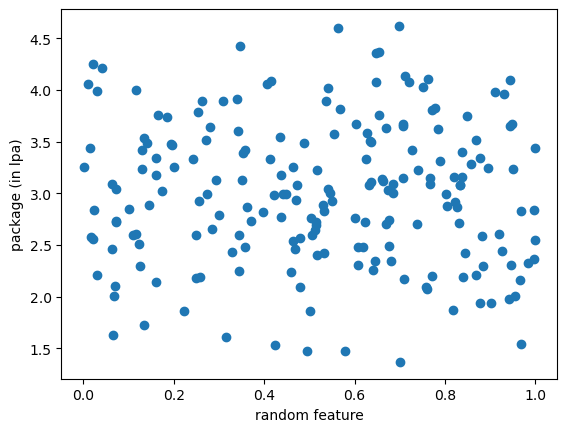

In [38]:
plt.scatter(new_df1['Random Feature'], new_df1['package'])
plt.xlabel('random feature')
plt.ylabel('package (in lpa)')

In [ ]:
X = new_df1.iloc[:, 0:2]
Y = new_df1.iloc[:, -1]

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=2, test_size=0.2)

In [43]:
lr = LinearRegression()

In [44]:
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred = lr.predict(X_test)

In [46]:
print("R2 Score", r2_score(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

R2 Score 0.7803261984715926


In [48]:
1 - ((1 - r2)*(40-1)/(40-1-2))

0.7684519389295166

### Adding relevant column and calculating R2 Score

In [49]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, 200)/10)

new_df2  = new_df2[['cgpa', 'iq', 'package']]

new_df2.head()

,cgpa,iq,package
0,6.89,2.46,3.26
1,5.12,2.88,1.98
2,7.82,2.35,3.25
3,7.42,3.97,3.67
4,6.94,4.67,3.57


Text(0, 0.5, 'package (in lpa)')

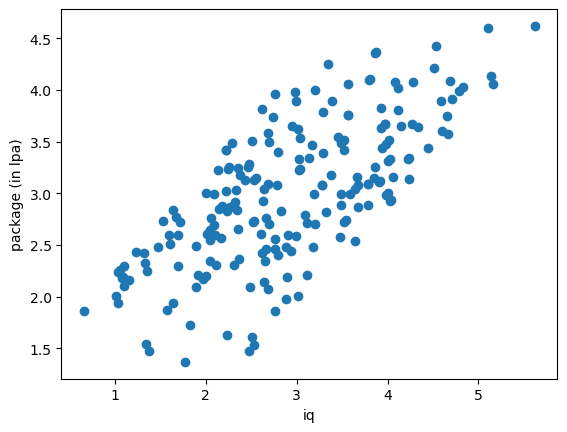

In [52]:
plt.scatter(new_df2['iq'], new_df2['package'])
plt.xlabel('iq')
plt.ylabel('package (in lpa)')

In [54]:
np.random.randint(-100, 100)

-33

In [55]:
X = new_df2.iloc[:, 0:2]
Y = new_df2.iloc[:, -1]

In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=2, test_size=0.2)

In [57]:
lr = LinearRegression()

In [58]:
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
y_pred = lr.predict(X_test)

In [62]:
print('R2 Score', r2_score(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

R2 Score 0.8417502463606107


In [63]:
# Adjusted R2 Score

1 - ((1 - r2)*(40-1)/(40-1-1))

0.8375857791595741